In [ ]:
#XLM-R+BiLSTM For Amharic Medical Question Classification
#Dataset: AmhMedQA.csv and ICHI.csv
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from torch.optim import  AdamW
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
#Load Datase
Amh = pd.read_csv("/content/drive/MyDrive/PHD folder/QA dataset/AmHQA2690.csv")
ICHI=pd.read_csv("/content/drive/MyDrive/PHD folder/QA dataset/ICHI.csv")
#

In [ ]:
#preprocessing
# ============================================================
# Experiment 1: ICHI Dataset
# Part 1: Data Preparation & XLM-R Embedding Extraction
# XLM-R + PCA Dimension Reduction
# Google Colab GPU
# ============================================================

# 1. Import Libraries
import os
import random
import numpy as np
import pandas as pd
import torch

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

from transformers import AutoTokenizer, AutoModel

# 2. Check GPU
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("="*60)
print("Device:",device)

if torch.cuda.is_available():
    print("GPU:",torch.cuda.get_device_name(0))

print("="*60)

# 3. Reproducibility
SEED=42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 4. Load Dataset
df=pd.read_csv("/content/drive/MyDrive/PHD folder/QA dataset/ICHI.csv")
print(df.head())
print(df.shape)

# 5. Data Cleaning
df=df[['Question','Category']]

df.dropna(inplace=True)

df.drop_duplicates(inplace=True)

df.reset_index(drop=True,inplace=True)

print("Dataset Shape:",df.shape)

# 6. Encode Labels
encoder=LabelEncoder()

df["Label"]=encoder.fit_transform(df["Category"])

print("\nClasses")

for i,c in enumerate(encoder.classes_):
    print(i,c)

np.save(
    "class_names.npy",
    encoder.classes_
)

# 7. Train Validation Test Split
train_texts,test_texts,train_labels,test_labels=train_test_split(
    df["Question"],
    df["Label"],
    test_size=0.20,
    random_state=SEED,
    stratify=df["Label"]
)

train_texts,val_texts,train_labels,val_labels=train_test_split(
    train_texts,
    train_labels,
    test_size=0.10,
    random_state=SEED,
    stratify=train_labels
)

print("Training:",len(train_texts))
print("Validation:",len(val_texts))
print("Testing:",len(test_texts))

# 8. Load XLM-R
MODEL_NAME="xlm-roberta-base"

tokenizer=AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model=AutoModel.from_pretrained(
    MODEL_NAME
)

model.to(device)

model.eval()

# 9. Extract XLM-R Embeddings
MAX_LEN=128
BATCH_SIZE=16

@torch.no_grad()
def get_embeddings(texts):

    embeddings=[]

    texts=list(texts)

    for start in tqdm(range(0,len(texts),BATCH_SIZE)):

        batch=texts[start:start+BATCH_SIZE]

        encoded=tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=MAX_LEN,
            return_tensors="pt"
        )

        encoded={
            k:v.to(device)
            for k,v in encoded.items()
        }

        outputs=model(**encoded)

        cls_embedding=outputs.last_hidden_state[:,0,:]

        embeddings.append(
            cls_embedding.cpu().numpy()
        )

    return np.vstack(embeddings)

# 10. Generate Embeddings
print("Extracting Training Embeddings...")
X_train=get_embeddings(train_texts)

print("Extracting Validation Embeddings...")
X_val=get_embeddings(val_texts)

print("Extracting Test Embeddings...")
X_test=get_embeddings(test_texts)

y_train=np.array(train_labels)
y_val=np.array(val_labels)
y_test=np.array(test_labels)


print("\nOriginal Embedding Dimension")
print(X_train.shape)

# ============================================================
# 11. PCA Dimension Reduction
# ============================================================

REDUCED_DIM=256

pca=PCA(
    n_components=REDUCED_DIM,
    random_state=SEED
)

# Fit PCA only on training data
X_train=pca.fit_transform(
    X_train
)

X_val=pca.transform(
    X_val
)

X_test=pca.transform(
    X_test
)

print("\nReduced Embedding Dimension")

print("Train:",X_train.shape)
print("Validation:",X_val.shape)
print("Test:",X_test.shape)

# Save PCA model
import pickle

with open(
    "xlmr_pca.pkl",
    "wb"
) as f:
    pickle.dump(
        pca,
        f
    )

# ============================================================
# 12. Save Embeddings
# ============================================================

np.save(
    "X_train.npy",
    X_train
)

np.save(
    "X_val.npy",
    X_val
)

np.save(
    "X_test.npy",
    X_test
)

np.save(
    "y_train.npy",
    y_train
)

np.save(
    "y_val.npy",
    y_val
)

np.save(
    "y_test.npy",
    y_test
)

print("\nReduced Embeddings Saved Successfully")

# ============================================================
# 13. Display Sample
# ============================================================

print("\nSample Reduced Embedding")

print(X_train[0][:20])

print(
    "Final Dimension:",
    X_train.shape[1]
)

# ============================================================
# 14. Save Label Mapping
# ============================================================

label_map=pd.DataFrame({
    "Class":encoder.classes_,
    "Encoded":range(len(encoder.classes_))
})

label_map.to_csv(
    "label_mapping.csv",
    index=False
)

print("\nLabel Mapping")

print(label_map)

print("\nPart 1 Completed Successfully")

Device: cuda
GPU: Tesla T4
  Category                         Title  \
0     DISE              Interrupt TX ???   
1     SOCL           Swollen vagina clit   
2     GOAL           burning yellow eyes   
3     SOCL              Drug test and ws   
4     FAML  4 year old is out of control   

                                            Question             Concepts  
0  Hi All! I am new here but have been lurking fo...                  NaN  
1  My girlfriend and i just got through having se...                  NaN  
2  Dr. i have dirty yellow buning eyes since my t...  condition|eyes|HAND  
3  Hi, a few nights ago I went to a gay sexclub a...                  NaN  
4  my 4 year old is a nightmare. me and my husban...       demanding|fits  
(11000, 4)
Dataset Shape: (10984, 2)

Classes
0 DEMO
1 DISE
2 FAML
3 GOAL
4 PREG
5 SOCL
6 TRMT
Training: 7908
Validation: 879
Testing: 2197


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

...

Extracting Validation Embeddings...


100%|██████████| 55/55 [00:06<00:00,  8.62it/s]


Extracting Test Embeddings...


100%|██████████| 138/138 [00:15<00:00,  8.80it/s]



Original Embedding Dimension
(7908, 768)

Reduced Embedding Dimension
Train: (7908, 256)
Validation: (879, 256)
Test: (2197, 256)

Reduced Embeddings Saved Successfully

Sample Reduced Embedding
[ 0.2823825   0.1714896   0.10153046  0.08422506 -0.0252203   0.10621545
 -0.16231996  0.06154676  0.04481635 -0.00955981 -0.00313224  0.07769641
  0.0041704  -0.06232852 -0.03657816 -0.0690309  -0.03182773 -0.10209835
  0.00423931  0.0072718 ]
Final Dimension: 256

Label Mapping
  Class  Encoded
0  DEMO        0
1  DISE        1
2  FAML        2
3  GOAL        3
4  PREG        4
5  SOCL        5
6  TRMT        6

Part 1 Completed Successfully


  Category                         Title  \
0     DISE              Interrupt TX ???   
1     SOCL           Swollen vagina clit   
2     GOAL           burning yellow eyes   
3     SOCL              Drug test and ws   
4     FAML  4 year old is out of control   

                                            Question             Concepts  
0  Hi All! I am new here but have been lurking fo...                  NaN  
1  My girlfriend and i just got through having se...                  NaN  
2  Dr. i have dirty yellow buning eyes since my t...  condition|eyes|HAND  
3  Hi, a few nights ago I went to a gay sexclub a...                  NaN  
4  my 4 year old is a nightmare. me and my husban...       demanding|fits  

Class Distribution Before SMOTE
Category
DEMO    1586
DISE    1629
FAML    1529
GOAL    1574
PREG    1619
SOCL    1558
TRMT    1505
Name: count, dtype: int64


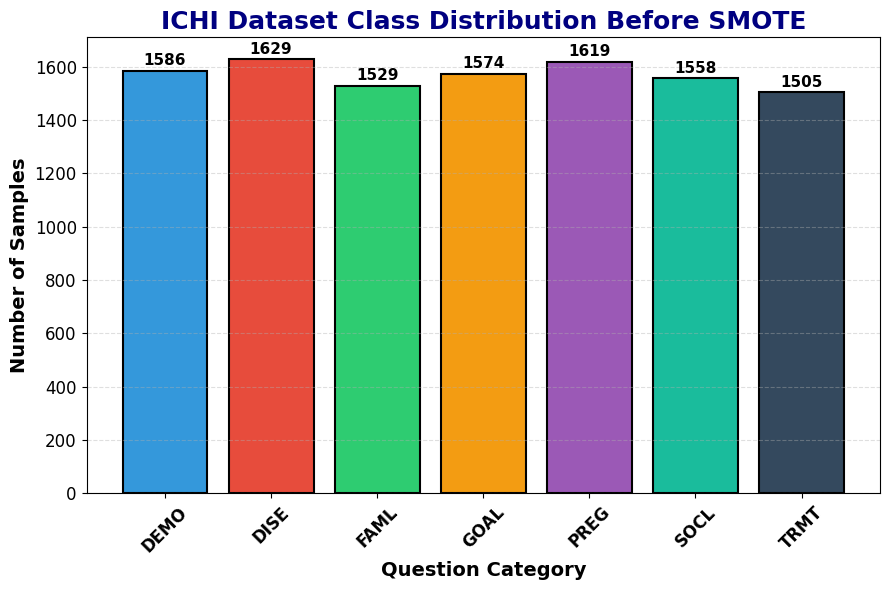


Class Distribution After SMOTE
Category
DEMO    1629
DISE    1629
FAML    1629
GOAL    1629
PREG    1629
SOCL    1629
TRMT    1629
Name: count, dtype: int64


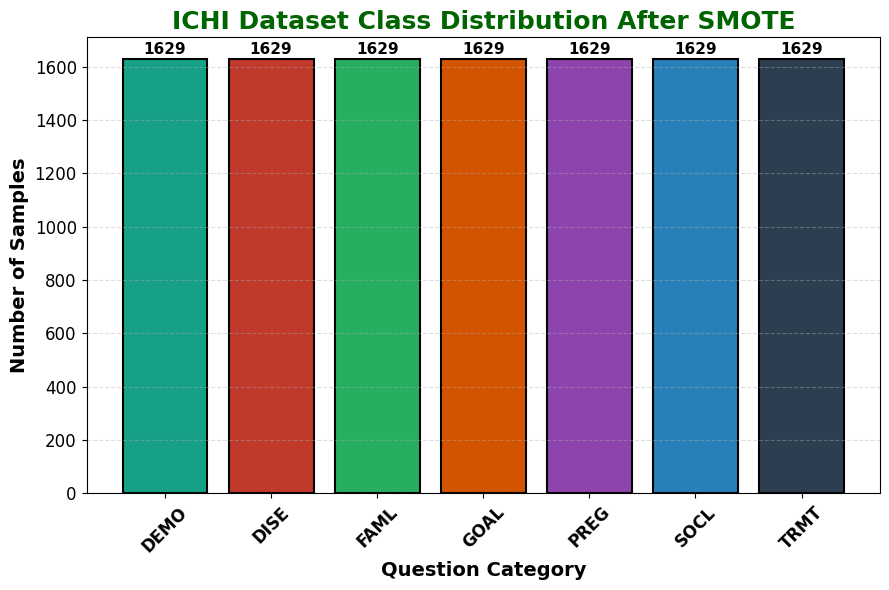


Counter Before SMOTE
Counter({'DISE': 1629, 'PREG': 1619, 'DEMO': 1586, 'GOAL': 1574, 'SOCL': 1558, 'FAML': 1529, 'TRMT': 1505})

Counter After SMOTE
Counter({'DISE': 1629, 'SOCL': 1629, 'GOAL': 1629, 'FAML': 1629, 'PREG': 1629, 'DEMO': 1629, 'TRMT': 1629})

Distribution table saved successfully!


In [ ]:
#Preprocessing
import pandas as pd
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
ICHI=pd.read_csv("/content/drive/MyDrive/PHD folder/QA dataset/ICHI.csv")
print(ICHI.head())
before=ICHI["Category"].value_counts().sort_index()
print("\nClass Distribution Before SMOTE")
print(before)
plt.figure(figsize=(9,6))
colors=["#3498db","#e74c3c","#2ecc71","#f39c12","#9b59b6","#1abc9c","#34495e"]
bars=plt.bar(before.index.astype(str),before.values,color=colors[:len(before)],edgecolor="black",linewidth=1.5)
plt.title("ICHI Dataset Class Distribution Before SMOTE",fontsize=18,fontweight="bold",color="navy")
plt.xlabel("Question Category",fontsize=14,fontweight="bold")
plt.ylabel("Number of Samples",fontsize=14,fontweight="bold")
plt.grid(axis="y",linestyle="--",alpha=0.4)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+20,str(int(bar.get_height())),ha="center",fontsize=11,fontweight="bold")
plt.xticks(fontsize=12,fontweight="bold",rotation=45)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig("IHCIBeforSmote.png",dpi=300,bbox_inches="tight")
plt.show()
X=ICHI["Question"]
y=ICHI["Category"]
vectorizer=TfidfVectorizer(max_features=5000)
X_vec=vectorizer.fit_transform(X)
smote=SMOTE(random_state=42)
X_smote,y_smote=smote.fit_resample(X_vec,y)
after=pd.Series(y_smote).value_counts().sort_index()
print("\nClass Distribution After SMOTE")
print(after)
plt.figure(figsize=(9,6))
colors2=["#16a085","#c0392b","#27ae60","#d35400","#8e44ad","#2980b9","#2c3e50"]
bars=plt.bar(after.index.astype(str),after.values,color=colors2[:len(after)],edgecolor="black",linewidth=1.5)
plt.title("ICHI Dataset Class Distribution After SMOTE",fontsize=18,fontweight="bold",color="darkgreen")
plt.xlabel("Question Category",fontsize=14,fontweight="bold")
plt.ylabel("Number of Samples",fontsize=14,fontweight="bold")
plt.grid(axis="y",linestyle="--",alpha=0.4)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+20,str(int(bar.get_height())),ha="center",fontsize=11,fontweight="bold")
plt.xticks(fontsize=12,fontweight="bold",rotation=45)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig("IHCIAfterSmote.png",dpi=300,bbox_inches="tight")
plt.show()
print("\nCounter Before SMOTE")
print(Counter(y))
print("\nCounter After SMOTE")
print(Counter(y_smote))
comparison=pd.DataFrame({"Before_SMOTE":before,"After_SMOTE":after})
comparison.to_csv("ICHI_SMOTE_distribution.csv")
print("\nDistribution table saved successfully!")

                              Question  \
0         የጥርስ እንክብካቤ እንዴት መከላከል ይቻላል?   
1               የልብ ጤና ምን ምልክቶች ይኖሩታል?   
2                ኢንፍሉዌንዛ ለእጅግ አደገኛ ነው?   
3  የስኳር በሽታ ከመደበኛ ምግብ ጋር ምን ግንኙነት አለው?   
4            የህፃናት ጤና እንዴት መከላከል ይቻላል?   

                                              Answer     Category  label  
0  የጥርስ እንክብካቤ ብዙውን ጊዜ በአካል እንቅስቃሴ እና በጤናማ መመገብ ይ...   definition    0.0  
1     የልብ ጤና ምልክቶቹ በሰው ሰው ይለያያሉ ፣ ግን ብዙ ጊዜ ታዋቂ ይሆናሉ።         list    3.0  
2    ኢንፍሉዌንዛ ምልክቶቹ በሰው ሰው ይለያያሉ ፣ ግን ብዙ ጊዜ ታዋቂ ይሆናሉ።         list    3.0  
3                የስኳር በሽታ በመቆጣጠር እና በመመገብ ሊቀንስ ይችላል።  description    1.0  
4   የህፃናት ጤና ምልክቶቹ በሰው ሰው ይለያያሉ ፣ ግን ብዙ ጊዜ ታዋቂ ይሆናሉ።   definition    0.0  

Class Distribution Before SMOTE
Category
definition      463
description    1131
factoid         289
list            808
Name: count, dtype: int64


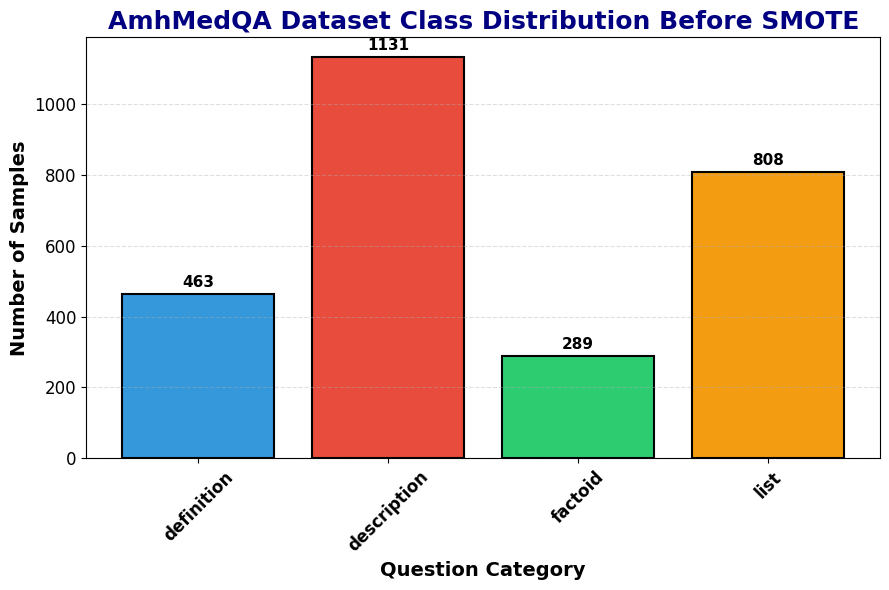


Class Distribution After SMOTE
Category
definition     1131
description    1131
factoid        1131
list           1131
Name: count, dtype: int64


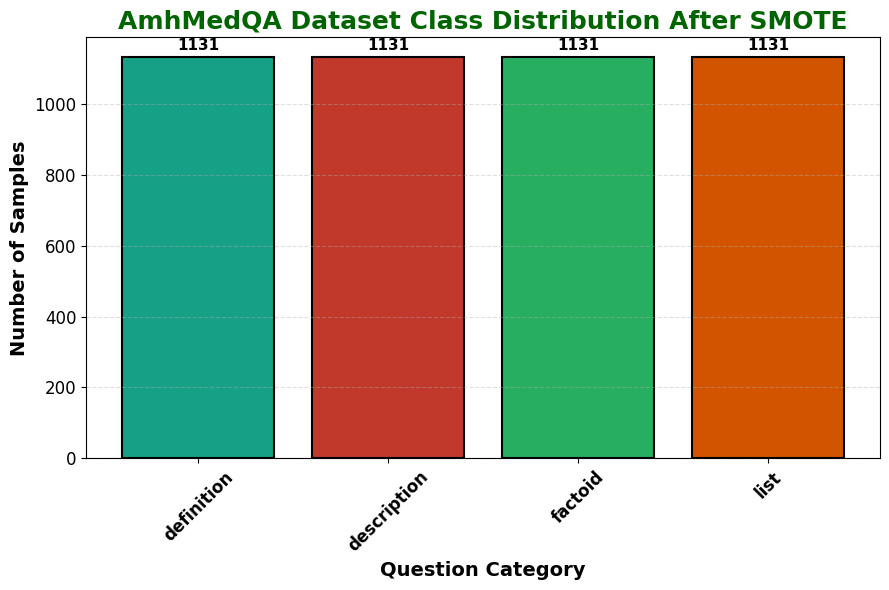


Counter Before SMOTE
Counter({'description': 1131, 'list': 808, 'definition': 463, 'factoid': 289})

Counter After SMOTE
Counter({'definition': 1131, 'list': 1131, 'description': 1131, 'factoid': 1131})

Distribution table saved successfully!


In [ ]:
#AmhMedQA dataset
import pandas as pd
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
Amh=pd.read_csv("/content/drive/MyDrive/PHD folder/QA dataset/AmHQA2690.csv")
print(Amh.head())
before=Amh["Category"].value_counts().sort_index()
print("\nClass Distribution Before SMOTE")
print(before)
plt.figure(figsize=(9,6))
colors=["#3498db","#e74c3c","#2ecc71","#f39c12","#9b59b6","#1abc9c","#34495e","#e67e22","#95a5a6"]
bars=plt.bar(before.index.astype(str),before.values,color=colors[:len(before)],edgecolor="black",linewidth=1.5)
plt.title("AmhMedQA Dataset Class Distribution Before SMOTE",fontsize=18,fontweight="bold",color="navy")
plt.xlabel("Question Category",fontsize=14,fontweight="bold")
plt.ylabel("Number of Samples",fontsize=14,fontweight="bold")
plt.grid(axis="y",linestyle="--",alpha=0.4)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+20,str(int(bar.get_height())),ha="center",fontsize=11,fontweight="bold")
plt.xticks(fontsize=12,fontweight="bold",rotation=45)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig("AmhMedQABeforSmote.png",dpi=300,bbox_inches="tight")
plt.show()
X=Amh["Question"]
y=Amh["Category"]
vectorizer=TfidfVectorizer(max_features=5000)
X_vec=vectorizer.fit_transform(X)
smote=SMOTE(random_state=42)
X_smote,y_smote=smote.fit_resample(X_vec,y)
after=pd.Series(y_smote).value_counts().sort_index()
print("\nClass Distribution After SMOTE")
print(after)
plt.figure(figsize=(9,6))
colors2=["#16a085","#c0392b","#27ae60","#d35400","#8e44ad","#2980b9","#2c3e50","#f1c40f","#7f8c8d"]
bars=plt.bar(after.index.astype(str),after.values,color=colors2[:len(after)],edgecolor="black",linewidth=1.5)
plt.title("AmhMedQA Dataset Class Distribution After SMOTE",fontsize=18,fontweight="bold",color="darkgreen")
plt.xlabel("Question Category",fontsize=14,fontweight="bold")
plt.ylabel("Number of Samples",fontsize=14,fontweight="bold")
plt.grid(axis="y",linestyle="--",alpha=0.4)
for bar in bars:
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height()+20,str(int(bar.get_height())),ha="center",fontsize=11,fontweight="bold")
plt.xticks(fontsize=12,fontweight="bold",rotation=45)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.savefig("AmhMedQAAfterSmote.png",dpi=300,bbox_inches="tight")
plt.show()
print("\nCounter Before SMOTE")
print(Counter(y))
print("\nCounter After SMOTE")
print(Counter(y_smote))
comparison=pd.DataFrame({"Before_SMOTE":before,"After_SMOTE":after})
comparison.to_csv("AmhMedQA_SMOTE_distribution.csv")
print("\nDistribution table saved successfully!")

Number of classes: 7
Train: 7040, Val: 1760, Test: 2200


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting embeddings...
PCA reduced dimension: 200
Starting training...
Epoch  1/15 | Train Loss: 1.3019 | Val Loss: 1.0887
Epoch  2/15 | Train Loss: 1.0307 | Val Loss: 1.0527
Epoch  3/15 | Train Loss: 0.9814 | Val Loss: 1.0406
Epoch  4/15 | Train Loss: 0.9509 | Val Loss: 1.0514
Epoch  5/15 | Train Loss: 0.9310 | Val Loss: 1.0445
Epoch  6/15 | Train Loss: 0.9128 | Val Loss: 1.0411
Epoch  7/15 | Train Loss: 0.8996 | Val Loss: 1.0637
Epoch  8/15 | Train Loss: 0.8850 | Val Loss: 1.0773
Epoch  9/15 | Train Loss: 0.8639 | Val Loss: 1.0554
Epoch 10/15 | Train Loss: 0.8451 | Val Loss: 1.0738
Epoch 11/15 | Train Loss: 0.8360 | Val Loss: 1.0759
Epoch 12/15 | Train Loss: 0.8194 | Val Loss: 1.0887
Epoch 13/15 | Train Loss: 0.7879 | Val Loss: 1.1513
Epoch 14/15 | Train Loss: 0.7725 | Val Loss: 1.1353
Epoch 15/15 | Train Loss: 0.7604 | Val Loss: 1.1112


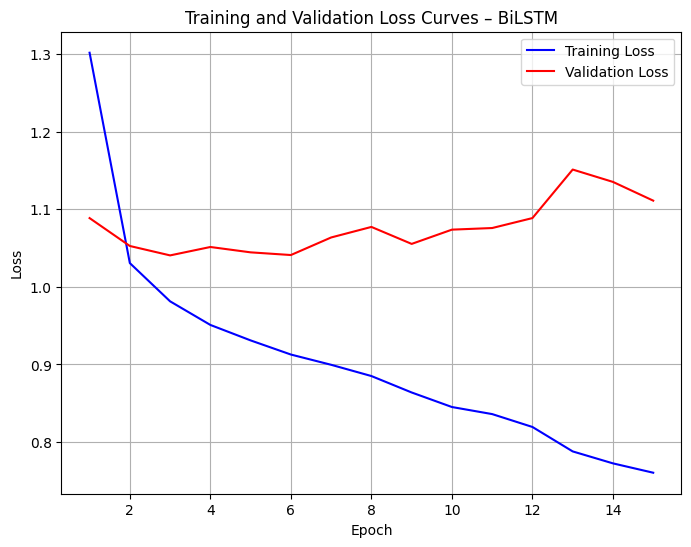


Classification Report (Test Set):
              precision    recall  f1-score   support

        DEMO       0.52      0.47      0.49       317
        DISE       0.55      0.63      0.59       326
        FAML       0.83      0.89      0.86       306
        GOAL       0.73      0.77      0.75       315
        PREG       0.70      0.59      0.64       324
        SOCL       0.61      0.60      0.61       311
        TRMT       0.58      0.57      0.58       301

    accuracy                           0.65      2200
   macro avg       0.64      0.65      0.64      2200
weighted avg       0.64      0.65      0.64      2200



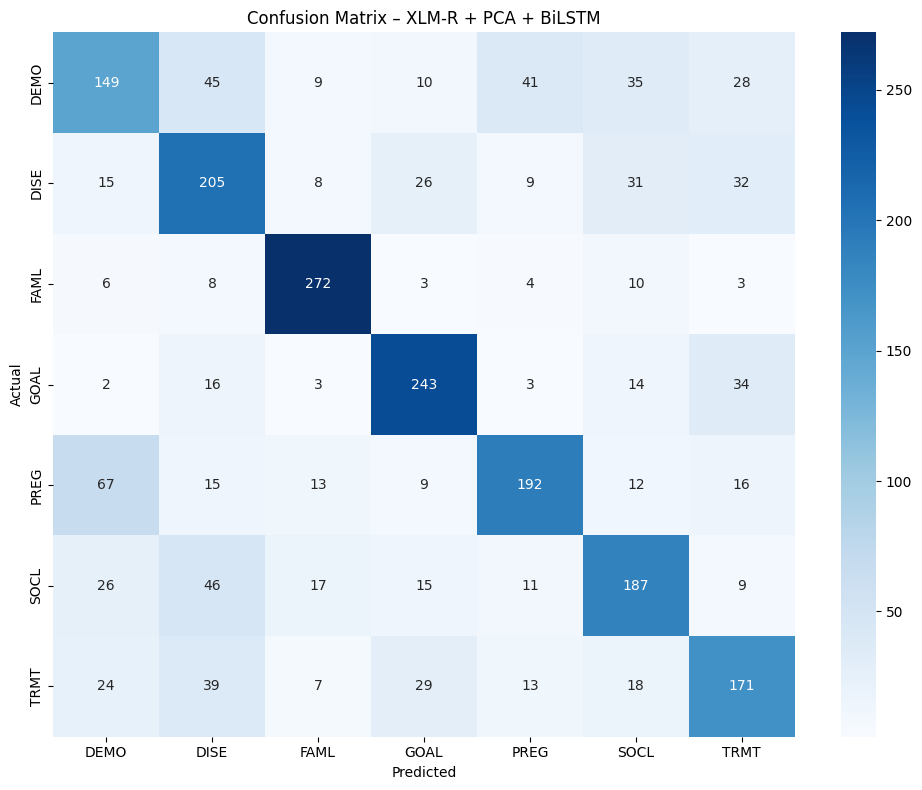

In [ ]:
#XLM-R+BiLSTM using ICHI dataset
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import XLMRobertaTokenizer, XLMRobertaModel
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 1. Load and prepare dataset
# ------------------------------
df = pd.read_csv("/content/drive/MyDrive/PHD folder/QA dataset/ICHI.csv")
TEXT_COL = 'Question'          # adjust to your column name
LABEL_COL = 'Category'         # adjust to your column name

# Clean data
df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df = df[df[TEXT_COL].str.strip() != '']   # remove empty strings

# Encode labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df[LABEL_COL])
num_classes = len(le.classes_)
print(f"Number of classes: {num_classes}")

# Split into train+val (80%) and test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    df[TEXT_COL].values,
    df['label_encoded'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label_encoded']
)

# Split train+val into train (80% of temp) and val (20% of temp)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_temp
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# ------------------------------
# 2. Load XLM-R tokenizer & model (feature extractor)
# ------------------------------
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
xlm_model = XLMRobertaModel.from_pretrained('xlm-roberta-base')
xlm_model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
xlm_model.to(device)

# ------------------------------
# 3. Extract XLM‑R [CLS] embeddings
# ------------------------------
def get_xlm_embeddings(texts, batch_size=16, max_len=128):
    """Extract the [CLS] token embedding from XLM‑R."""
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = [str(t) for t in texts[i:i+batch_size]]  # force strings
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors='pt'
        )
        input_ids = encoded['input_ids'].to(device)
        attention_mask = encoded['attention_mask'].to(device)
        with torch.no_grad():
            outputs = xlm_model(input_ids, attention_mask=attention_mask)
            # Use the [CLS] token representation
            cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_emb)
    return np.vstack(embeddings)

print("Extracting embeddings...")
X_train_emb = get_xlm_embeddings(X_train)
X_val_emb = get_xlm_embeddings(X_val)
X_test_emb = get_xlm_embeddings(X_test)

# ------------------------------
# 4. PCA dimensionality reduction
# ------------------------------
n_components = 200   # you can adjust this
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_emb)
X_val_pca = pca.transform(X_val_emb)
X_test_pca = pca.transform(X_test_emb)

print(f"PCA reduced dimension: {X_train_pca.shape[1]}")

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_pca, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val_pca, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test_pca, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# ------------------------------
# 5. BiLSTM classifier (bidirectional)
# ------------------------------
class BiLSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super(BiLSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,               # <-- key change
            dropout=dropout if num_layers > 1 else 0
        )
        # Linear layer takes hidden_size * 2 because bidirectional
        self.fc = nn.Linear(hidden_size * 2, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, input_size)
        x = x.unsqueeze(1)                      # (batch, 1, input_size)
        lstm_out, (h_n, c_n) = self.lstm(x)    # h_n: (num_layers*2, batch, hidden_size)
        # Take the last layer's forward and backward hidden states
        h_forward = h_n[-2, :, :]   # forward from last layer
        h_backward = h_n[-1, :, :]  # backward from last layer
        h_concat = torch.cat((h_forward, h_backward), dim=1)  # (batch, hidden_size*2)
        out = self.dropout(h_concat)
        out = self.fc(out)
        return out

# Hyperparameters
input_size = n_components
hidden_size = 128
num_layers = 2
learning_rate = 2e-3
batch_size = 16
epochs = 15

model = BiLSTMClassifier(input_size, hidden_size, num_layers, num_classes).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# ------------------------------
# 6. Training loop with validation loss tracking
# ------------------------------
train_losses = []
val_losses = []

print("Starting training...")
for epoch in range(epochs):
    # Training phase
    model.train()
    total_train_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation phase
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            total_val_loss += loss.item()
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# ------------------------------
# 7. Plot training vs. validation loss
# ------------------------------
def plot_loss_curves(train_losses, val_losses):
    epochs_range = range(1, len(train_losses) + 1)
    plt.figure(figsize=(8, 6))
    plt.plot(epochs_range, train_losses, 'b-', label='Training Loss')
    plt.plot(epochs_range, val_losses, 'r-', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves – BiLSTM')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss_curves(train_losses, val_losses)

# ------------------------------
# 8. Evaluate on test set
# ------------------------------
model.eval()
with torch.no_grad():
    logits = model(X_test_t.to(device))
    preds = torch.argmax(logits, dim=1).cpu().numpy()

print("\nClassification Report (Test Set):")
print(classification_report(y_test, preds, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – XLM‑R + PCA + BiLSTM')
plt.tight_layout()
plt.show()

Number of classes: 4
Train: 1721, Val: 431, Test: 539


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting embeddings...
PCA reduced dimension: 200
Starting training...
Epoch  1/15 | Train Loss: 1.0729 | Val Loss: 0.8188
Epoch  2/15 | Train Loss: 0.5564 | Val Loss: 0.4937
Epoch  3/15 | Train Loss: 0.3700 | Val Loss: 0.4333
Epoch  4/15 | Train Loss: 0.3038 | Val Loss: 0.4754
Epoch  5/15 | Train Loss: 0.2863 | Val Loss: 0.4094
Epoch  6/15 | Train Loss: 0.2522 | Val Loss: 0.4163
Epoch  7/15 | Train Loss: 0.2307 | Val Loss: 0.4827
Epoch  8/15 | Train Loss: 0.2235 | Val Loss: 0.4376
Epoch  9/15 | Train Loss: 0.2087 | Val Loss: 0.4407
Epoch 10/15 | Train Loss: 0.2031 | Val Loss: 0.4622
Epoch 11/15 | Train Loss: 0.1881 | Val Loss: 0.4954
Epoch 12/15 | Train Loss: 0.1880 | Val Loss: 0.5023
Epoch 13/15 | Train Loss: 0.1777 | Val Loss: 0.4980
Epoch 14/15 | Train Loss: 0.1647 | Val Loss: 0.5406
Epoch 15/15 | Train Loss: 0.1672 | Val Loss: 0.5425


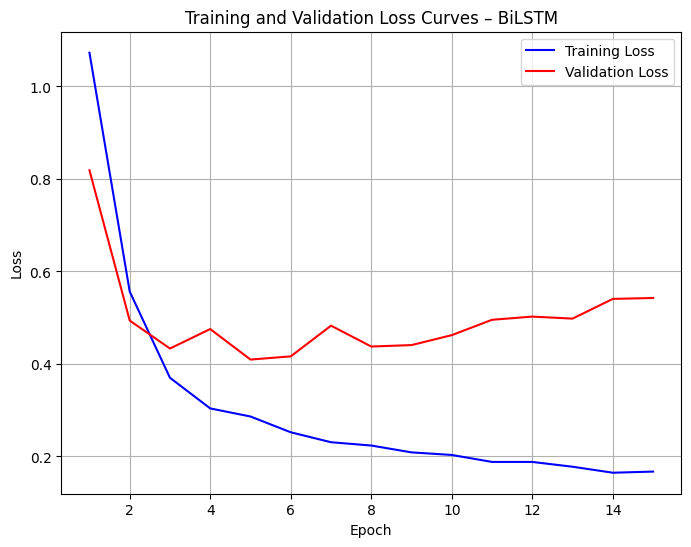


Classification Report (Test Set):
              precision    recall  f1-score   support

  definition       0.85      0.62      0.72        93
 description       0.82      0.87      0.84       226
     factoid       0.81      0.88      0.84        58
        list       0.87      0.91      0.89       162

    accuracy                           0.84       539
   macro avg       0.84      0.82      0.82       539
weighted avg       0.84      0.84      0.84       539



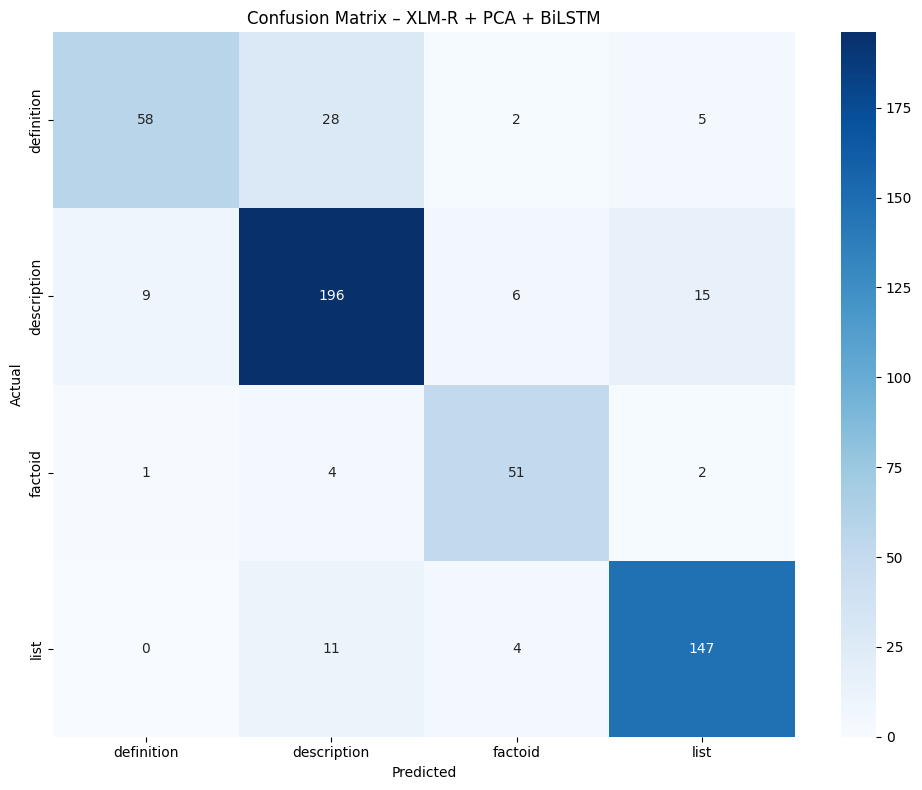

In [ ]:
#XLM-R+BiLSTM using AmhMedQA dataset
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import XLMRobertaTokenizer, XLMRobertaModel
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 1. Load and prepare dataset
# ------------------------------
df = pd.read_csv("/content/drive/MyDrive/PHD folder/QA dataset/AmHQA2690.csv")

TEXT_COL = 'Question'          # adjust to your column name
LABEL_COL = 'Category'         # adjust to your column name

# Clean data
df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df = df[df[TEXT_COL].str.strip() != '']   # remove empty strings

# Encode labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df[LABEL_COL])
num_classes = len(le.classes_)
print(f"Number of classes: {num_classes}")

# Split into train+val (80%) and test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    df[TEXT_COL].values,
    df['label_encoded'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label_encoded']
)

# Split train+val into train (80% of temp) and val (20% of temp)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_temp
)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# ------------------------------
# 2. Load XLM-R tokenizer & model (feature extractor)
# ------------------------------
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
xlm_model = XLMRobertaModel.from_pretrained('xlm-roberta-base')
xlm_model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
xlm_model.to(device)

# ------------------------------
# 3. Extract XLM‑R [CLS] embeddings
# ------------------------------
def get_xlm_embeddings(texts, batch_size=16, max_len=128):
    """Extract the [CLS] token embedding from XLM‑R."""
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = [str(t) for t in texts[i:i+batch_size]]  # force strings
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors='pt'
        )
        input_ids = encoded['input_ids'].to(device)
        attention_mask = encoded['attention_mask'].to(device)
        with torch.no_grad():
            outputs = xlm_model(input_ids, attention_mask=attention_mask)
            # Use the [CLS] token representation
            cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_emb)
    return np.vstack(embeddings)

print("Extracting embeddings...")
X_train_emb = get_xlm_embeddings(X_train)
X_val_emb = get_xlm_embeddings(X_val)
X_test_emb = get_xlm_embeddings(X_test)

# ------------------------------
# 4. PCA dimensionality reduction
# ------------------------------
n_components = 200   # you can adjust this
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_emb)
X_val_pca = pca.transform(X_val_emb)
X_test_pca = pca.transform(X_test_emb)

print(f"PCA reduced dimension: {X_train_pca.shape[1]}")

# Convert to PyTorch tensors
X_train_t = torch.tensor(X_train_pca, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val_pca, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test_pca, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# ------------------------------
# 5. BiLSTM classifier (bidirectional)
# ------------------------------
class BiLSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.3):
        super(BiLSTMClassifier, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,               # <-- key change
            dropout=dropout if num_layers > 1 else 0
        )
        # Linear layer takes hidden_size * 2 because bidirectional
        self.fc = nn.Linear(hidden_size * 2, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        # x: (batch, input_size)
        x = x.unsqueeze(1)                      # (batch, 1, input_size)
        lstm_out, (h_n, c_n) = self.lstm(x)    # h_n: (num_layers*2, batch, hidden_size)
        # Take the last layer's forward and backward hidden states
        h_forward = h_n[-2, :, :]   # forward from last layer
        h_backward = h_n[-1, :, :]  # backward from last layer
        h_concat = torch.cat((h_forward, h_backward), dim=1)  # (batch, hidden_size*2)
        out = self.dropout(h_concat)
        out = self.fc(out)
        return out

# Hyperparameters
input_size = n_components
hidden_size = 128
num_layers = 2
learning_rate = 2e-3
batch_size = 16
epochs = 15

model = BiLSTMClassifier(input_size, hidden_size, num_layers, num_classes).to(device)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# ------------------------------
# 6. Training loop with validation loss tracking
# ------------------------------
train_losses = []
val_losses = []

print("Starting training...")
for epoch in range(epochs):
    # Training phase
    model.train()
    total_train_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation phase
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            total_val_loss += loss.item()
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# ------------------------------
# 7. Plot training vs. validation loss
# ------------------------------
def plot_loss_curves(train_losses, val_losses):
    epochs_range = range(1, len(train_losses) + 1)
    plt.figure(figsize=(8, 6))
    plt.plot(epochs_range, train_losses, 'b-', label='Training Loss')
    plt.plot(epochs_range, val_losses, 'r-', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves – BiLSTM')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss_curves(train_losses, val_losses)

# ------------------------------
# 8. Evaluate on test set
# ------------------------------
model.eval()
with torch.no_grad():
    logits = model(X_test_t.to(device))
    preds = torch.argmax(logits, dim=1).cpu().numpy()

print("\nClassification Report (Test Set):")
print(classification_report(y_test, preds, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – XLM‑R + PCA + BiLSTM')
plt.tight_layout()
plt.show()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



AmhMedQA
Extracting XLM-R features...
Applying PCA...
Epoch 1/10 Train Loss:1.2893 Validation Loss:1.1270
Epoch 2/10 Train Loss:1.0729 Validation Loss:0.9048
Epoch 3/10 Train Loss:0.9288 Validation Loss:0.8578
Epoch 4/10 Train Loss:0.8952 Validation Loss:0.7683
Epoch 5/10 Train Loss:0.8239 Validation Loss:0.8150
Epoch 6/10 Train Loss:0.7921 Validation Loss:0.7756
Epoch 7/10 Train Loss:0.7642 Validation Loss:0.7232
Epoch 8/10 Train Loss:0.7140 Validation Loss:0.6719
Epoch 9/10 Train Loss:0.6768 Validation Loss:0.6166
Epoch 10/10 Train Loss:0.6528 Validation Loss:0.5966

Classification Report

              precision    recall  f1-score   support

  definition       0.59      0.54      0.56        93
 description       0.78      0.85      0.82       226
     factoid       0.69      0.43      0.53        58
        list       0.83      0.89      0.86       161

    accuracy                           0.76       538
   macro avg       0.72      0.68      0.69       538
weighted avg       0

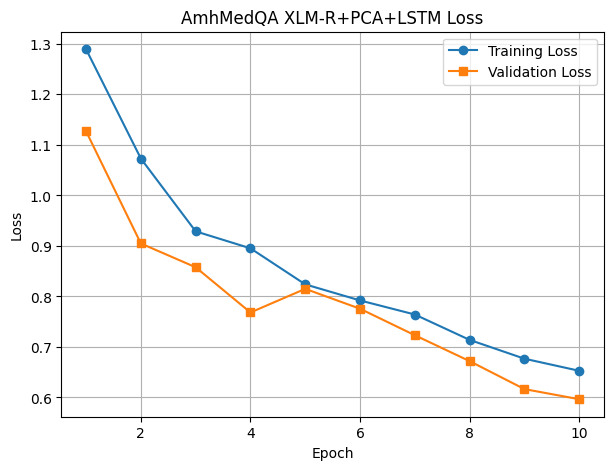

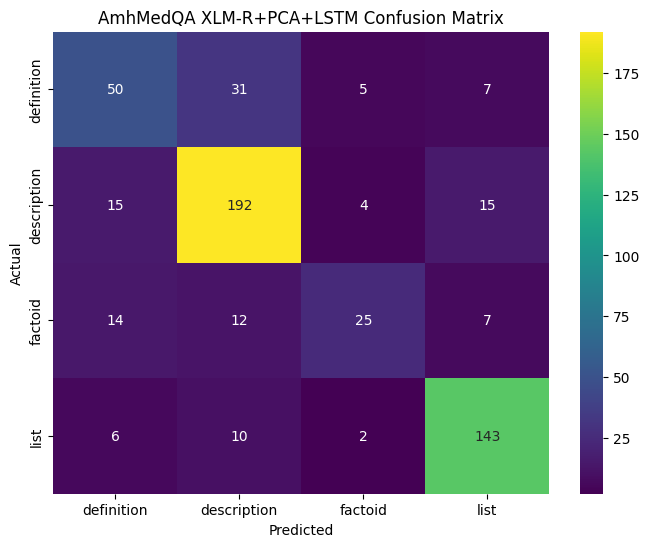


ICHI
Extracting XLM-R features...
Applying PCA...
Epoch 1/10 Train Loss:1.8357 Validation Loss:1.6922
Epoch 2/10 Train Loss:1.5752 Validation Loss:1.4946
Epoch 3/10 Train Loss:1.4637 Validation Loss:1.4789
Epoch 4/10 Train Loss:1.4220 Validation Loss:1.4452
Epoch 5/10 Train Loss:1.3375 Validation Loss:1.3357
Epoch 6/10 Train Loss:1.3136 Validation Loss:1.3564
Epoch 7/10 Train Loss:1.2713 Validation Loss:1.2937
Epoch 8/10 Train Loss:1.3071 Validation Loss:1.2956
Epoch 9/10 Train Loss:1.3891 Validation Loss:1.3428
Epoch 10/10 Train Loss:1.2554 Validation Loss:1.2979

Classification Report

              precision    recall  f1-score   support

        DEMO       0.33      0.24      0.28       275
        DISE       0.37      0.62      0.46       305
        FAML       0.88      0.88      0.88       252
        GOAL       0.65      0.73      0.68       294
        PREG       0.54      0.59      0.56       264
        SOCL       0.55      0.52      0.54       270
        TRMT       0.48  

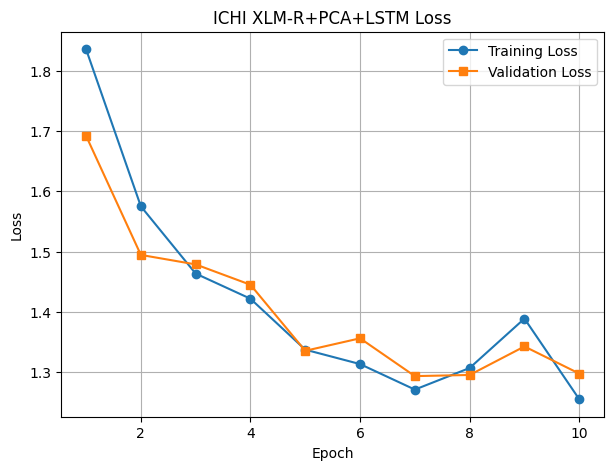

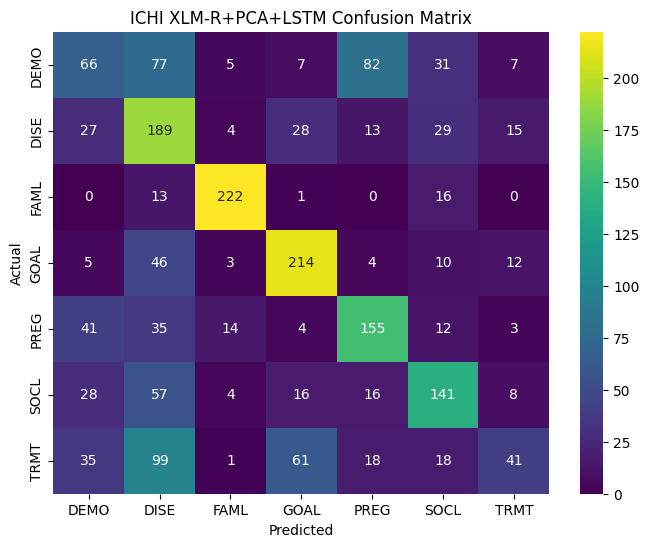

In [ ]:
#===========================================================
# XLM-R + PCA + LSTM Classifier for AmHQA2690 and ICHI
#===========================================================
import torch,random
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import Dataset,DataLoader
from transformers import AutoTokenizer,AutoModel
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report,confusion_matrix
from torch.optim import AdamW
import matplotlib.pyplot as plt
import seaborn as sns
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed=42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
#-----------------------------------------------------------
# XLM-R Encoder
#-----------------------------------------------------------
tokenizer=AutoTokenizer.from_pretrained("xlm-roberta-base")
xlmr=AutoModel.from_pretrained("xlm-roberta-base").to(device)
xlmr.eval()
PCA_DIM=200
pca=PCA(n_components=PCA_DIM)
#-----------------------------------------------------------
# Extract XLM-R embeddings
#-----------------------------------------------------------
def extract_embeddings(texts,batch_size=16,max_len=128):
    output_embeddings=[]
    with torch.no_grad():
        for i in range(0,len(texts),batch_size):
            batch=texts[i:i+batch_size]
            encoded=tokenizer(
                batch,
                padding="max_length",
                truncation=True,
                max_length=max_len,
                return_tensors="pt"
            )

            ids=encoded["input_ids"].to(device)
            mask=encoded["attention_mask"].to(device)

            outputs=xlmr(
                input_ids=ids,
                attention_mask=mask
            )

            output_embeddings.append(
                outputs.last_hidden_state.cpu().numpy()
            )
    return np.concatenate(output_embeddings,axis=0)
#-----------------------------------------------------------
# PCA reduction
#-----------------------------------------------------------
def reduce_pca(features,fit=False):
    samples,seq,dim=features.shape
    flat=features.reshape(-1,dim)
    if fit:
        flat=pca.fit_transform(flat)
    else:
        flat=pca.transform(flat)
    return torch.tensor(
        flat.reshape(samples,seq,PCA_DIM),
        dtype=torch.float32 )
#-----------------------------------------------------------
# Dataset
#-----------------------------------------------------------
class FeatureDataset(Dataset):
    def __init__(self,x,y):
        self.x=x
        self.y=torch.tensor(
            y,
            dtype=torch.long        )
    def __len__(self):
        return len(self.y)
    def __getitem__(self,index):
        return self.x[index],self.y[index]
#-----------------------------------------------------------
# XLM-R + PCA + LSTM Model
#-----------------------------------------------------------
class XLMR_PCA_LSTM(nn.Module):
    def __init__(self,num_classes):
        super().__init__()
        self.lstm=nn.LSTM(
            input_size=PCA_DIM,
            hidden_size=128,
            batch_first=True,
            bidirectional=False
        )
        self.dropout=nn.Dropout(0.1)
        self.fc=nn.Linear(
            128,
            num_classes        )
    def forward(self,x):
        _,(hidden,cell)=self.lstm(x)
        hidden=hidden[-1]
        hidden=self.dropout(hidden)
        return self.fc(hidden)
#-----------------------------------------------------------
# Experiment Function
#-----------------------------------------------------------
def run_experiment(df,dataset_name):
    print("\n================================")
    print(dataset_name)
    print("================================")
    df=df.dropna()
    texts=df["Question"].astype(str).tolist()
    labels=df["Category"].astype(str).tolist()
    encoder=LabelEncoder()
    labels=encoder.fit_transform(labels)
    train_text,test_text,train_y,test_y=train_test_split(
        texts,
        labels,
        test_size=0.2,
        stratify=labels,
        random_state=42    )
    train_text,val_text,train_y,val_y=train_test_split(
        train_text,
        train_y,
        test_size=0.1,
        stratify=train_y,
        random_state=42 )
    print("Extracting XLM-R features...")
    train_emb=extract_embeddings(train_text)
    val_emb=extract_embeddings(val_text)
    test_emb=extract_embeddings(test_text)
    print("Applying PCA...")
    train_emb=reduce_pca(
        train_emb,
        fit=True    )
    val_emb=reduce_pca(
        val_emb    )
    test_emb=reduce_pca(
        test_emb    )
    train_loader=DataLoader(
        FeatureDataset(train_emb,train_y),
        batch_size=16,
        shuffle=True
    )
    val_loader=DataLoader(
        FeatureDataset(val_emb,val_y),
        batch_size=16)
    test_loader=DataLoader(
        FeatureDataset(test_emb,test_y),
        batch_size=16    )
    model=XLMR_PCA_LSTM(
        len(encoder.classes_)
    ).to(device)
    optimizer=AdamW(
        model.parameters(),
        lr=2e-4    )
    criterion=nn.CrossEntropyLoss()
    epochs=10
    train_losses=[]
    val_losses=[]
    for epoch in range(epochs):
        model.train()
        total_loss=0
        for x,y in train_loader:
            x=x.to(device)
            y=y.to(device)
            optimizer.zero_grad()
            pred=model(x)
            loss=criterion(
                pred,
                y)
            loss.backward()
            optimizer.step()
            total_loss+=loss.item()
        train_loss=total_loss/len(train_loader)
        model.eval()
        total_val=0
        with torch.no_grad():
            for x,y in val_loader:
                x=x.to(device)
                y=y.to(device)
                pred=model(x)
                loss=criterion(
                    pred,
                    y
                )
                total_val+=loss.item()
        val_loss=total_val/len(val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        print(
            f"Epoch {epoch+1}/{epochs} "
            f"Train Loss:{train_loss:.4f} "
            f"Validation Loss:{val_loss:.4f}"
        )
    #-------------------------------------------------------
    # Evaluation
    #-------------------------------------------------------
    model.eval()
    y_pred=[]
    y_true=[]
    with torch.no_grad():
        for x,y in test_loader:
            x=x.to(device)
            output=model(x)
            pred=torch.argmax(
                output,
                dim=1            )
            y_pred.extend(
                pred.cpu().numpy()            )
            y_true.extend(
                y.numpy()            )
    print("\nClassification Report\n")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=encoder.classes_))
    #-------------------------------------------------------
    # Loss plot
    #-------------------------------------------------------
    plt.figure(figsize=(7,5))
    plt.plot(
        range(1,epochs+1),
        train_losses,
        marker="o",
        label="Training Loss"    )
    plt.plot(
        range(1,epochs+1),
        val_losses,
        marker="s",
        label="Validation Loss"    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(
        dataset_name+
        " XLM-R+PCA+LSTM Loss"    )
    plt.legend()
    plt.grid()
    plt.show()
    #-------------------------------------------------------
    # Confusion Matrix
   #-------------------------------------------------------
    cm=confusion_matrix(
        y_true,
        y_pred    )
    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="viridis",
        xticklabels=encoder.classes_,
        yticklabels=encoder.classes_
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(
        dataset_name+
        " XLM-R+PCA+LSTM Confusion Matrix"
    )
    plt.show()
#===========================================================
# Load datasets
#===========================================================
Amh=pd.read_csv(
"/content/drive/MyDrive/PHD folder/QA dataset/AmHQA2690.csv"
)
ICHI=pd.read_csv(
"/content/drive/MyDrive/PHD folder/QA dataset/ICHI.csv"
)
#===========================================================
# Run AmhMedQA
#===========================================================
run_experiment(
    Amh,
    "AmhMedQA")
#===========================================================
# Run ICHI
#===========================================================
run_experiment(
    ICHI,
    "ICHI")

Number of classes: 7
Train size: 7040, Val size: 1760, Test size: 2200


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.12GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting embeddings...
PCA reduced dimension: 200
Starting training...
Epoch 1/15 | Train Loss: 1.9448 | Val Loss: 1.9300
Epoch 2/15 | Train Loss: 1.8889 | Val Loss: 1.8360
Epoch 3/15 | Train Loss: 1.7836 | Val Loss: 1.7448
Epoch 4/15 | Train Loss: 1.7060 | Val Loss: 1.6809
Epoch 5/15 | Train Loss: 1.6634 | Val Loss: 1.6440
Epoch 6/15 | Train Loss: 1.6258 | Val Loss: 1.6063
Epoch 7/15 | Train Loss: 1.5994 | Val Loss: 1.5785
Epoch 8/15 | Train Loss: 1.5633 | Val Loss: 1.5488
Epoch 9/15 | Train Loss: 1.5312 | Val Loss: 1.5018
Epoch 10/15 | Train Loss: 1.4982 | Val Loss: 1.4691
Epoch 11/15 | Train Loss: 1.4616 | Val Loss: 1.4387
Epoch 12/15 | Train Loss: 1.4407 | Val Loss: 1.4173
Epoch 13/15 | Train Loss: 1.4223 | Val Loss: 1.4017
Epoch 14/15 | Train Loss: 1.4032 | Val Loss: 1.4133
Epoch 15/15 | Train Loss: 1.3986 | Val Loss: 1.3988


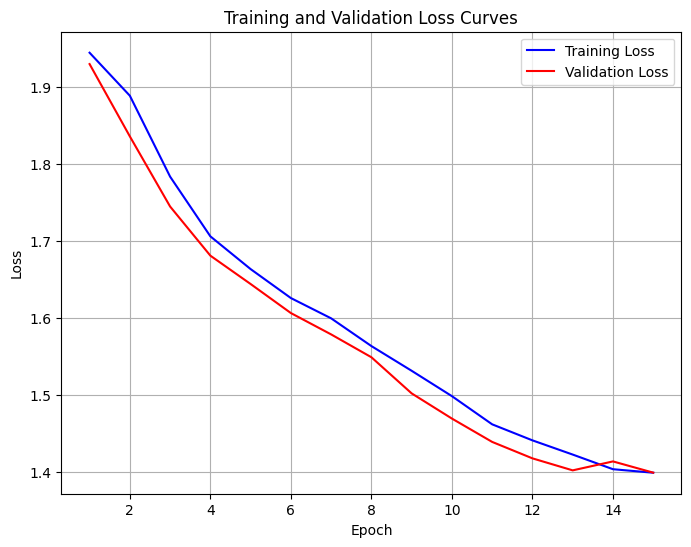


Classification Report (Test Set):
              precision    recall  f1-score   support

        DEMO       0.31      0.47      0.37       317
        DISE       0.37      0.29      0.32       326
        FAML       0.79      0.81      0.80       306
        GOAL       0.56      0.49      0.52       315
        PREG       0.43      0.52      0.47       324
        SOCL       0.38      0.41      0.39       311
        TRMT       0.39      0.19      0.26       301

    accuracy                           0.45      2200
   macro avg       0.46      0.45      0.45      2200
weighted avg       0.46      0.45      0.45      2200



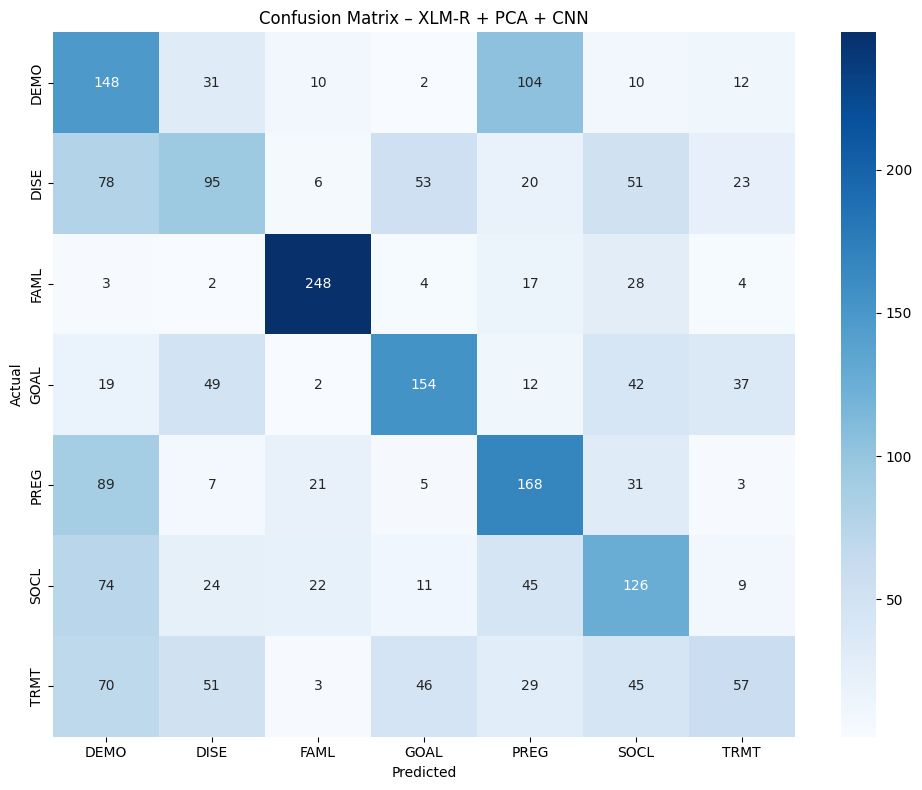

In [ ]:
#XLM-R+CNN using ICHI
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import XLMRobertaTokenizer, XLMRobertaModel
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# 1. Load dataset
# ------------------------------
df = pd.read_csv("/content/drive/MyDrive/PHD folder/QA dataset/ICHI.csv")
TEXT_COL = 'Question'
LABEL_COL = 'Category'

df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df = df[df[TEXT_COL].str.strip() != '']

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df[LABEL_COL])
num_classes = len(le.classes_)
print(f"Number of classes: {num_classes}")

# Split into train+val and test (80/20)
X_temp, X_test, y_temp, y_test = train_test_split(
    df[TEXT_COL].values,
    df['label_encoded'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label_encoded']
)

# Further split train+val into train and validation (80% of temp = 64% of total, 20% of temp = 16% of total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.2,          # 20% of temp becomes validation
    random_state=42,
    stratify=y_temp
)

print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

# ------------------------------
# 2. XLM-R tokenizer & model
# ------------------------------
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
xlm_model = XLMRobertaModel.from_pretrained('xlm-roberta-base')
xlm_model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
xlm_model.to(device)

# ------------------------------
# 3. Extract XLM‑R embeddings (train, val, test)
# ------------------------------
def get_xlm_embeddings(texts, batch_size=16, max_len=128):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = [str(t) for t in texts[i:i+batch_size]]
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors='pt'
        )
        input_ids = encoded['input_ids'].to(device)
        attention_mask = encoded['attention_mask'].to(device)
        with torch.no_grad():
            outputs = xlm_model(input_ids, attention_mask=attention_mask)
            cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_emb)
    return np.vstack(embeddings)

print("Extracting embeddings...")
X_train_emb = get_xlm_embeddings(X_train)
X_val_emb = get_xlm_embeddings(X_val)
X_test_emb = get_xlm_embeddings(X_test)

# ------------------------------
# 4. PCA (fit on train only, transform all)
# ------------------------------
n_components = 200
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_emb)
X_val_pca = pca.transform(X_val_emb)
X_test_pca = pca.transform(X_test_emb)

print(f"PCA reduced dimension: {X_train_pca.shape[1]}")

# Convert to tensors
X_train_t = torch.tensor(X_train_pca, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val_pca, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test_pca, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# ------------------------------
# 5. CNN classifier
# ------------------------------
class CNNClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=0.3):
        super(CNNClassifier, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)                     # (batch, 1, input_dim)
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.adaptive_pool(x)              # (batch, 128, 1)
        x = x.view(x.size(0), -1)              # (batch, 128)
        x = self.dropout(x)
        x = self.fc(x)
        return x

input_dim = n_components
learning_rate = 1e-3
batch_size = 16
epochs = 15

model = CNNClassifier(input_dim, num_classes).to(device)

# DataLoaders
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# ------------------------------
# 6. Training loop with validation loss tracking
# ------------------------------
train_losses = []
val_losses = []

print("Starting training...")
for epoch in range(epochs):
    # Training
    model.train()
    total_train_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            total_val_loss += loss.item()
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# ------------------------------
# 7. Plot loss curves
# ------------------------------
def plot_loss_curves(train_losses, val_losses):
    """Plot training and validation loss vs. epochs."""
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(8, 6))
    plt.plot(epochs, train_losses, 'b-', label='Training Loss')
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss_curves(train_losses, val_losses)

# ------------------------------
# 8. Evaluation on test set
# ------------------------------
model.eval()
with torch.no_grad():
    logits = model(X_test_t.to(device))
    preds = torch.argmax(logits, dim=1).cpu().numpy()

print("\nClassification Report (Test Set):")
print(classification_report(y_test, preds, target_names=le.classes_))

cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – XLM‑R + PCA + CNN')
plt.tight_layout()
plt.show()

Number of classes: 4

Class distribution in full dataset:
  definition: 463 samples
  description: 1131 samples
  factoid: 289 samples
  list: 808 samples

Train: 1721, Val: 431, Test: 539


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Extracting embeddings for train, val, test...
PCA reduced dimension: 200

Starting training...
Epoch  1/15 | Train Loss: 1.3875 | Val Loss: 1.3872
Epoch  2/15 | Train Loss: 1.3764 | Val Loss: 1.3542
Epoch  3/15 | Train Loss: 1.3333 | Val Loss: 1.3014
Epoch  4/15 | Train Loss: 1.2793 | Val Loss: 1.2590
Epoch  5/15 | Train Loss: 1.2437 | Val Loss: 1.2470
Epoch  6/15 | Train Loss: 1.2192 | Val Loss: 1.2219
Epoch  7/15 | Train Loss: 1.2162 | Val Loss: 1.2132
Epoch  8/15 | Train Loss: 1.1957 | Val Loss: 1.1914
Epoch  9/15 | Train Loss: 1.1825 | Val Loss: 1.1775
Epoch 10/15 | Train Loss: 1.1687 | Val Loss: 1.1641
Epoch 11/15 | Train Loss: 1.1537 | Val Loss: 1.1512
Epoch 12/15 | Train Loss: 1.1455 | Val Loss: 1.1410
Epoch 13/15 | Train Loss: 1.1360 | Val Loss: 1.1294
Epoch 14/15 | Train Loss: 1.1279 | Val Loss: 1.1151
Epoch 15/15 | Train Loss: 1.1042 | Val Loss: 1.1116


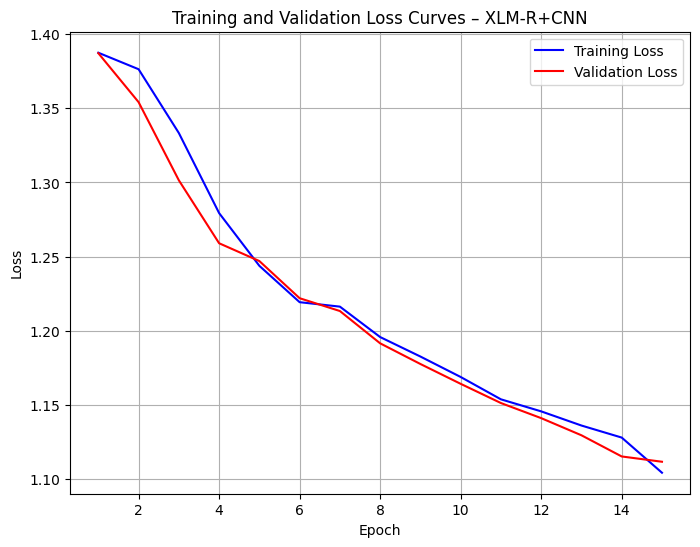


Classification Report (Test Set):
              precision    recall  f1-score   support

  definition       0.34      0.54      0.42        93
 description       0.68      0.39      0.50       226
     factoid       0.43      0.22      0.30        58
        list       0.57      0.81      0.67       162

    accuracy                           0.53       539
   macro avg       0.51      0.49      0.47       539
weighted avg       0.56      0.53      0.51       539



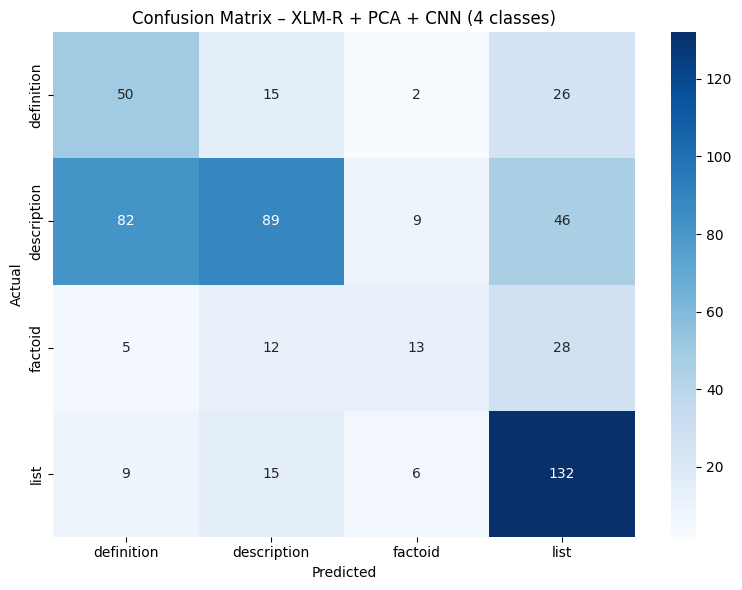

In [ ]:
#XLM-R+CNN for AmhMedQA dataset
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from transformers import XLMRobertaTokenizer, XLMRobertaModel
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# 1. Load and prepare dataset
# ================================
df = pd.read_csv("/content/drive/MyDrive/PHD folder/QA dataset/AmHQA2690.csv")  # adjust path if needed
TEXT_COL = 'Question'
LABEL_COL = 'Category'

df = df.dropna(subset=[TEXT_COL, LABEL_COL])
df = df[df[TEXT_COL].str.strip() != '']

le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df[LABEL_COL])
num_classes = len(le.classes_)
print(f"Number of classes: {num_classes}")

# Check class distribution
print("\nClass distribution in full dataset:")
for cls, count in zip(le.classes_, df['label_encoded'].value_counts().sort_index()):
    print(f"  {cls}: {count} samples")

# Split into train+val (80%) and test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    df[TEXT_COL].values,
    df['label_encoded'].values,
    test_size=0.2,
    random_state=42,
    stratify=df['label_encoded']
)

# Split train+val into train (80% of temp) and val (20% of temp)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_temp
)

print(f"\nTrain: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# ================================
# 2. Load XLM-R model (feature extractor)
# ================================
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
xlm_model = XLMRobertaModel.from_pretrained('xlm-roberta-base')
xlm_model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
xlm_model.to(device)

# ================================
# 3. Extract XLM‑R [CLS] embeddings
# ================================
def get_xlm_embeddings(texts, batch_size=16, max_len=128):
    embeddings = []
    for i in range(0, len(texts), batch_size):
        batch_texts = [str(t) for t in texts[i:i+batch_size]]
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors='pt'
        )
        input_ids = encoded['input_ids'].to(device)
        attention_mask = encoded['attention_mask'].to(device)
        with torch.no_grad():
            outputs = xlm_model(input_ids, attention_mask=attention_mask)
            cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_emb)
    return np.vstack(embeddings)

print("\nExtracting embeddings for train, val, test...")
X_train_emb = get_xlm_embeddings(X_train)
X_val_emb = get_xlm_embeddings(X_val)
X_test_emb = get_xlm_embeddings(X_test)

# ================================
# 4. PCA dimensionality reduction
# ================================
n_components = 200
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_emb)
X_val_pca = pca.transform(X_val_emb)
X_test_pca = pca.transform(X_test_emb)
print(f"PCA reduced dimension: {X_train_pca.shape[1]}")

# Convert to tensors
X_train_t = torch.tensor(X_train_pca, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val_pca, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test_pca, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# ================================
# 5. CNN classifier
# ================================
class CNNClassifier(nn.Module):
    def __init__(self, input_dim, num_classes, dropout=0.3):
        super(CNNClassifier, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

input_dim = n_components
learning_rate = 1e-3
batch_size = 16
epochs = 15

model = CNNClassifier(input_dim, num_classes).to(device)

# ---- Optional: class weighting for imbalanced data ----
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)   # uncomment to use
# if you don't want weighting, comment the above and use:
# criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# ================================
# 6. Training loop
# ================================
train_losses = []
val_losses = []

print("\nStarting training...")
for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            total_val_loss += loss.item()
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1:2d}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

# ================================
# 7. Plot loss curves
# ================================
def plot_loss_curves(train_losses, val_losses):
    epochs_range = range(1, len(train_losses) + 1)
    plt.figure(figsize=(8, 6))
    plt.plot(epochs_range, train_losses, 'b-', label='Training Loss')
    plt.plot(epochs_range, val_losses, 'r-', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss Curves – XLM‑R+CNN')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss_curves(train_losses, val_losses)

# ================================
# 8. Evaluation on test set (FIXED)
# ================================
model.eval()
with torch.no_grad():
    logits = model(X_test_t.to(device))
    preds = torch.argmax(logits, dim=1).cpu().numpy()

print("\nClassification Report (Test Set):")
# zero_division=0 avoids warnings for classes with no predicted samples
print(classification_report(y_test, preds, target_names=le.classes_, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – XLM‑R + PCA + CNN (4 classes)')
plt.tight_layout()
plt.show()

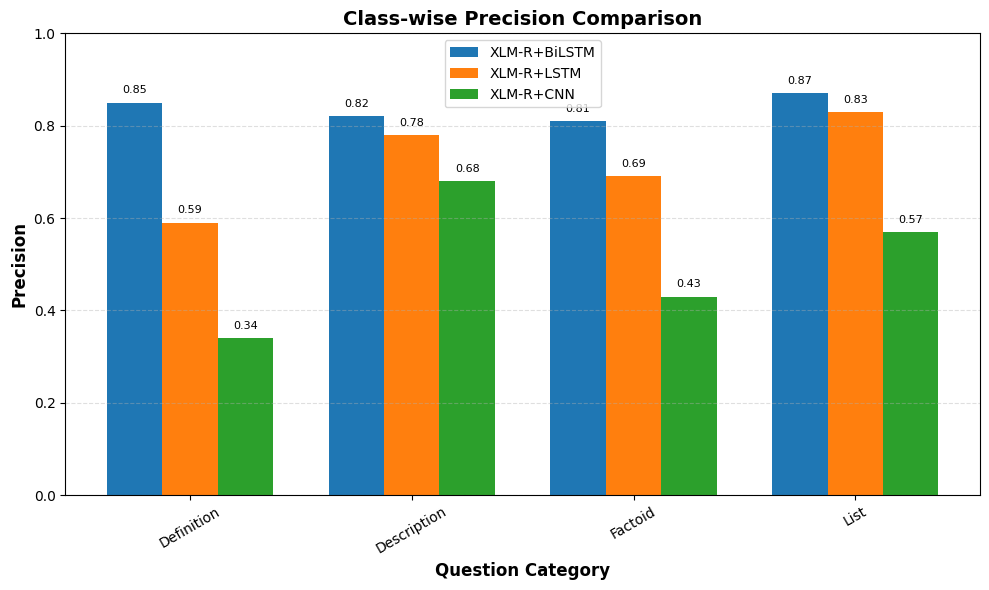

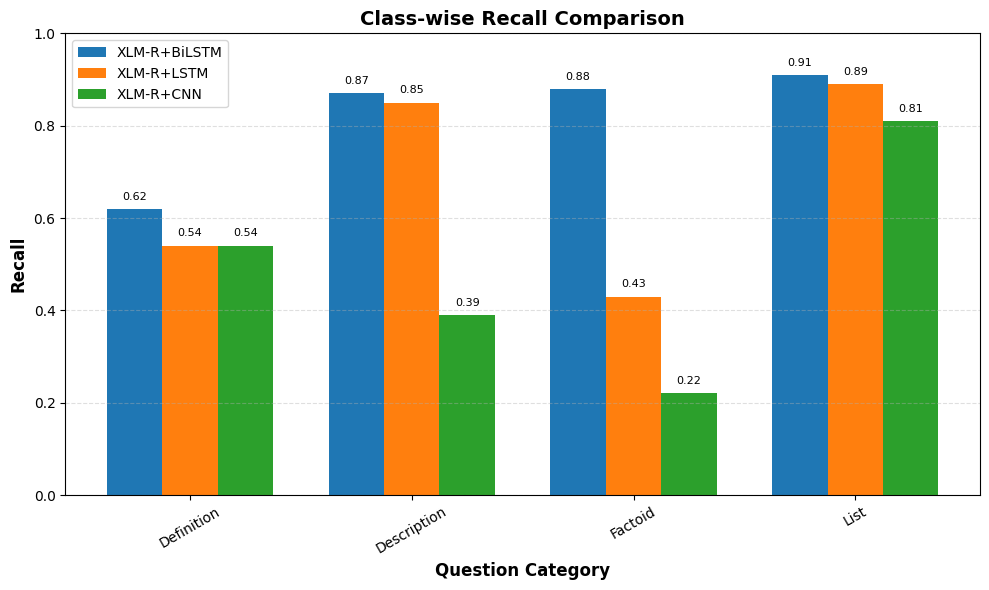

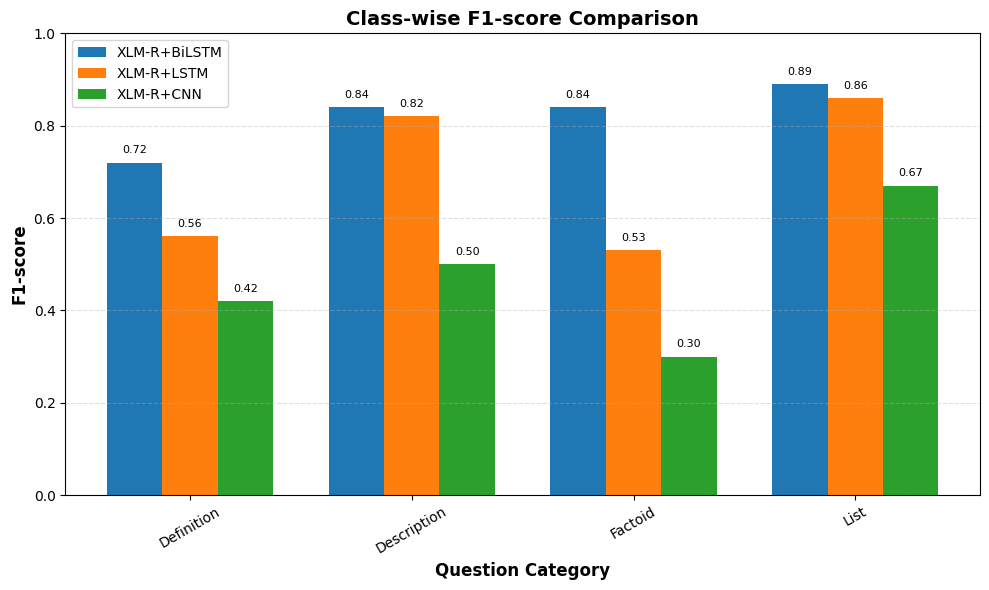

In [ ]:
#Experiment Results using AMhMedQA dataset
import matplotlib.pyplot as plt
import numpy as np

# Categories
categories=[
    "Definition",
    "Description",
    "Factoid",
    "List"
]

# XLM-R + BiLSTM
bilstm_p=[0.85,0.82,0.81,0.87]
bilstm_r=[0.62,0.87,0.88,0.91]
bilstm_f1=[0.72,0.84,0.84,0.89]

# XLM-R + LSTM
lstm_p=[0.59,0.78,0.69,0.83]
lstm_r=[0.54,0.85,0.43,0.89]
lstm_f1=[0.56,0.82,0.53,0.86]

# XLM-R + CNN
cnn_p=[0.34,0.68,0.43,0.57]
cnn_r=[0.54,0.39,0.22,0.81]
cnn_f1=[0.42,0.50,0.30,0.67]


def plot_metric(metric_name,bilstm,lstm,cnn,filename):

    x=np.arange(len(categories))
    width=0.25

    plt.figure(figsize=(10,6))

    plt.bar(
        x-width,
        bilstm,
        width,
        label="XLM-R+BiLSTM"
    )

    plt.bar(
        x,
        lstm,
        width,
        label="XLM-R+LSTM"
    )

    plt.bar(
        x+width,
        cnn,
        width,
        label="XLM-R+CNN"
    )

    plt.xlabel(
        "Question Category",
        fontsize=12,
        fontweight="bold"
    )

    plt.ylabel(
        metric_name,
        fontsize=12,
        fontweight="bold"
    )

    plt.title(
        f"Class-wise {metric_name} Comparison",
        fontsize=14,
        fontweight="bold"
    )

    plt.xticks(
        x,
        categories,
        rotation=30
    )

    plt.ylim(0,1)

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    plt.legend()

    # Add values
    for i,values in enumerate([bilstm,lstm,cnn]):
        for j,value in enumerate(values):
            plt.text(
                j+(i-1)*width,
                value+0.02,
                f"{value:.2f}",
                ha="center",
                fontsize=8
            )

    plt.tight_layout()

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# Precision plot
plot_metric(
    "Precision",
    bilstm_p,
    lstm_p,
    cnn_p,
    "Classwise_Precision_Comparison.png"
)

# Recall plot
plot_metric(
    "Recall",
    bilstm_r,
    lstm_r,
    cnn_r,
    "Classwise_Recall_Comparison.png"
)

# F1-score plot
plot_metric(
    "F1-score",
    bilstm_f1,
    lstm_f1,
    cnn_f1,
    "Classwise_F1_Comparison.png"
)

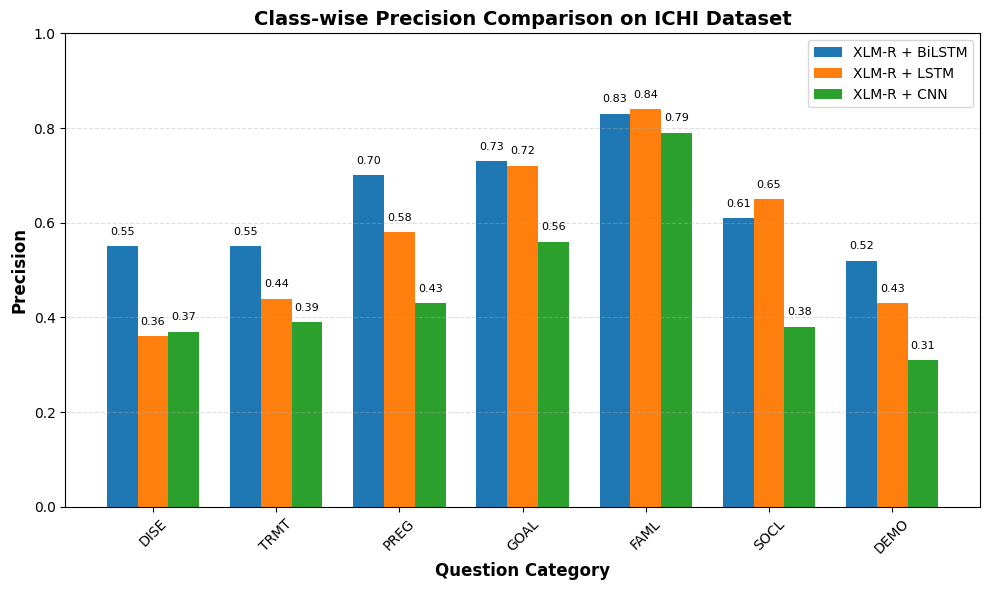

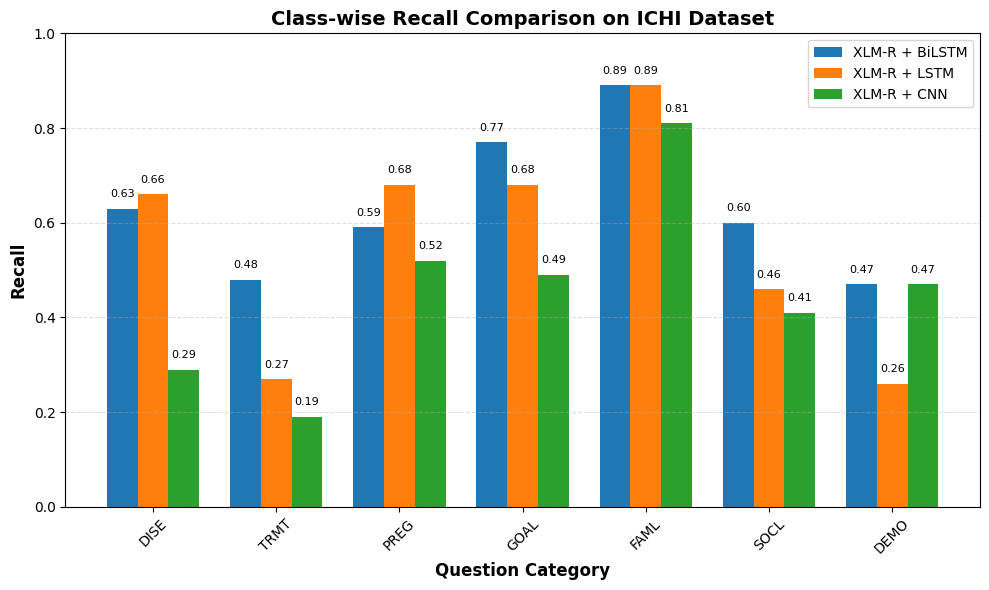

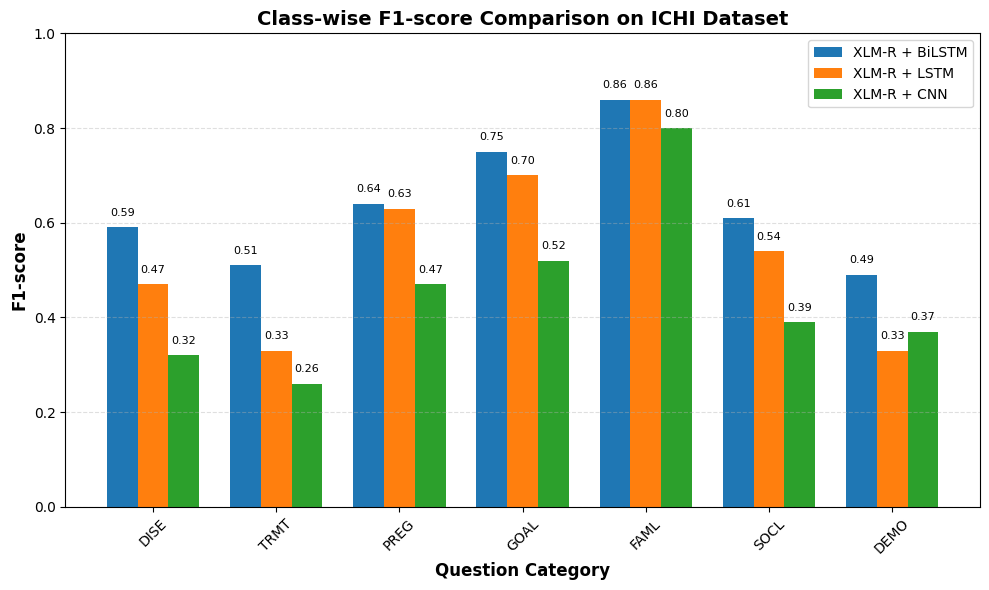

In [ ]:
#Sample Results using  ICHI dataset
import matplotlib.pyplot as plt
import numpy as np

# Classes
classes = ['DISE', 'TRMT', 'PREG', 'GOAL', 'FAML', 'SOCL', 'DEMO']

# XLM-R + BiLSTM
bilstm_p = [0.55, 0.55, 0.70, 0.73, 0.83, 0.61, 0.52]
bilstm_r = [0.63, 0.48, 0.59, 0.77, 0.89, 0.60, 0.47]
bilstm_f1 = [0.59, 0.51, 0.64, 0.75, 0.86, 0.61, 0.49]

# XLM-R + LSTM
lstm_p = [0.36, 0.44, 0.58, 0.72, 0.84, 0.65, 0.43]
lstm_r = [0.66, 0.27, 0.68, 0.68, 0.89, 0.46, 0.26]
lstm_f1 = [0.47, 0.33, 0.63, 0.70, 0.86, 0.54, 0.33]

# XLM-R + CNN
cnn_p = [0.37, 0.39, 0.43, 0.56, 0.79, 0.38, 0.31]
cnn_r = [0.29, 0.19, 0.52, 0.49, 0.81, 0.41, 0.47]
cnn_f1 = [0.32, 0.26, 0.47, 0.52, 0.80, 0.39, 0.37]
# Function to plot metrics
def plot_metric(metric_name, bilstm, lstm, cnn):
    x = np.arange(len(classes))
    width = 0.25

    plt.figure(figsize=(10,6))

    plt.bar(x - width, bilstm, width,
            label='XLM-R + BiLSTM')

    plt.bar(x, lstm, width,
            label='XLM-R + LSTM')
    plt.bar(x + width, cnn, width,
            label='XLM-R + CNN')
    plt.xlabel("Question Category", fontsize=12)
    plt.ylabel(metric_name, fontsize=12)
    plt.title(
        f"Class-wise {metric_name} Comparison on ICHI Dataset",
        fontsize=14,
        fontweight='bold'
    )

    plt.xticks(
        x,
        classes,
        rotation=45
    )

    plt.ylim(0,1)

    plt.legend()

    plt.grid(
        axis='y',
        linestyle='--',
        alpha=0.5
    )

    # Add values on bars
    for i, values in enumerate([bilstm,lstm,cnn]):
        for j,v in enumerate(values):
            plt.text(
                j+(i-1)*width,
                v+0.02,
                f"{v:.2f}",
                ha='center',
                fontsize=8
            )

    plt.tight_layout()

    plt.show()


# Plot Precision
plot_metric(
    "Precision",
    bilstm_p,
    lstm_p,
    cnn_p
)


# Plot Recall
plot_metric(
    "Recall",
    bilstm_r,
    lstm_r,
    cnn_r
)


# Plot F1-score
plot_metric(
    "F1-score",
    bilstm_f1,
    lstm_f1,
    cnn_f1
)

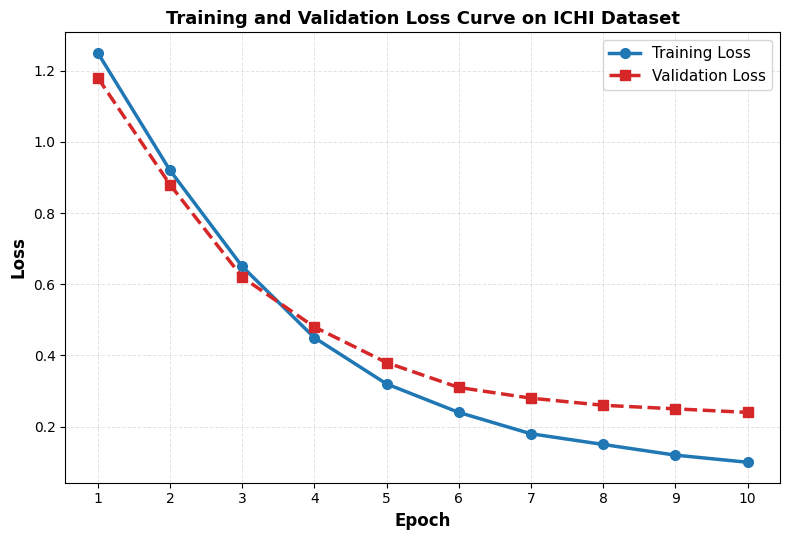

In [1]:
# ICHI dataset Performance: Training and Validation Loss Curve

import matplotlib.pyplot as plt

epochs = range(1, 11)

train_loss = [
    1.25, 0.92, 0.65, 0.45, 0.32,
    0.24, 0.18, 0.15, 0.12, 0.10
]

val_loss = [
    1.18, 0.88, 0.62, 0.48, 0.38,
    0.31, 0.28, 0.26, 0.25, 0.24
]

# Professional color scheme
train_color = "#1f77b4"   # Deep blue
val_color = "#d62728"     # Deep red

plt.figure(figsize=(8, 5.5))

plt.plot(
    epochs,
    train_loss,
    color=train_color,
    marker='o',
    markersize=7,
    linewidth=2.5,
    label='Training Loss'
)

plt.plot(
    epochs,
    val_loss,
    color=val_color,
    marker='s',
    markersize=7,
    linewidth=2.5,
    linestyle='--',
    label='Validation Loss'
)

# Labels and title
plt.xlabel("Epoch", fontsize=12, fontweight="bold")
plt.ylabel("Loss", fontsize=12, fontweight="bold")

plt.title(
    "Training and Validation Loss Curve on ICHI Dataset",
    fontsize=13,
    fontweight="bold"
)

# Axis formatting
plt.xticks(epochs, fontsize=10)
plt.yticks(fontsize=10)

# Grid style
plt.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.35
)

# Legend
plt.legend(
    fontsize=11,
    loc="upper right",
    frameon=True
)

plt.tight_layout()

# High-resolution output
plt.savefig(
    "ICHI_training_validation_loss.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()